# Introduction to Machine Learning: Supervised Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 2: Regression model evaluation

---

## Setup (do not edit)

In [36]:
import pathlib
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE: int = 42  # global seed for full reproducibility
np.random.seed(RANDOM_STATE)

_DATA_PATH = pathlib.Path("auto.csv")
if not _DATA_PATH.exists():
    raise FileNotFoundError(
        "auto.csv is missing from the lab directory. Please download it or ask the TA "
        "for assistance."
    )

## 1. Load the Dataset *(5 points)*

Write a function `load_auto_data()` that reads `auto.csv` into a `pandas.DataFrame`. Store the shape of the DataFrame in a variable called **`q1_shape`**.

In [37]:
def load_auto_data() -> pd.DataFrame:
    """Load the Auto dataset from ``auto.csv``.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing the auto dataset.
    """
    # your code here
#     raise NotImplementedError

    return pd.read_csv('auto.csv')


# Compute the answer required by the autograder
q1_shape: Tuple[int, int] = load_auto_data().shape

In [38]:
# If all tests pass (there might be hidden tests), you will earn 5 points
# Test Cell: Question 1
assert isinstance(q1_shape, tuple), "q1_shape must be a tuple"
assert len(q1_shape) == 2, "q1_shape should have 2 elements (rows, cols)"
assert q1_shape[0] > 0 and q1_shape[1] > 0, "Shape values must be positive"
print(f"Dataset shape: {q1_shape}")

Dataset shape: (392, 8)


## 2. Prepare Data *(10 points)*

Create the feature matrix `X` and target vector `y`.
- `X` should contain the columns: `displacement`, `horsepower`, `weight`, `acceleration`.
- `y` should contain the `mpg` column.
Store the number of features in **`q2_num_features`**.

In [74]:
df = load_auto_data()
# YOUR CODE HERE
# your code here
# raise NotImplementedError

display(df.describe())

display(df.head(2))

display(df["displacement"][:2])

# get pd.Series/Vector for predictors
X = df[["displacement", "horsepower", "weight", "acceleration"]]

# get pd.Series/Vector for target
y = df['mpg']

features = X_train.columns
q2_num_features = len(list(X.columns))


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1


0    307.0
1    350.0
Name: displacement, dtype: float64

In [40]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert "X" in locals() and "y" in locals(), "X and y must be defined."
assert isinstance(X, pd.DataFrame), "X should be a DataFrame"
assert isinstance(y, pd.Series), "y should be a Series"
assert isinstance(q2_num_features, int), "q2_num_features should be an integer"
assert q2_num_features > 0, "Number of features must be positive"
print(f"Number of features: {q2_num_features}")

Number of features: 4


## 3. Train/Test Split *(10 points)*

Perform an 80/20 split of `X` and `y`. Use `random_state=RANDOM_STATE`. Store the row counts of each split in a tuple **`q3_split_counts = (n_train, n_test)`**.

In [41]:
# YOUR CODE HERE
# your code here
# raise NotImplementedError

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

n_train = len(X_train)
n_test = len(X_test)

q3_split_counts = (n_train, n_test)

In [42]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert isinstance(q3_split_counts, tuple), "q3_split_counts must be a tuple"
assert len(q3_split_counts) == 2, "q3_split_counts should have 2 elements"
train_rows, test_rows = q3_split_counts
assert train_rows > 0 and test_rows > 0, "Both splits must have positive counts"
assert train_rows > test_rows, "Training set should be larger than test set"
print(f"Train rows: {train_rows}, Test rows: {test_rows}")

Train rows: 313, Test rows: 79


## 4. Train Linear Regression Model *(15 points)*

Train a `LinearRegression` model on the training data. Store the fitted model in a variable named **`model`**.

In [43]:
# YOUR CODE HERE
# your code here
# raise NotImplementedError


# ref @ 
# https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols_ridge.html
model = LinearRegression().fit(X_train, y_train)


In [44]:
# If all tests pass (there might be hidden tests), you will earn 15 points
# Test Cell: Question 4
assert "model" in locals(), "The 'model' variable is not defined."
assert hasattr(model, "fit"), "The model should have a 'fit' method."
assert hasattr(model, "predict"), "The model should have a 'predict' method."
assert hasattr(model, "coef_"), "The model has not been fitted yet."
print(f"Model trained successfully with {len(model.coef_)} coefficients")

Model trained successfully with 4 coefficients


## 5. Calculate Test MSE *(15 points)*

Use the trained model to make predictions on the test set, then compute the Mean Squared Error (MSE). Store the result in **`q5_mse`** (float, rounded to three decimals).

In [45]:
# YOUR CODE HERE
# your code here
# raise NotImplementedError

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

q5_mse = float(round(mse,3))


In [46]:
# If all tests pass (there might be hidden tests), you will earn 15 points
# Test Cell: Question 5
assert isinstance(q5_mse, float), "MSE must be a float."
assert q5_mse >= 0, "MSE must be non-negative."
assert q5_mse < 1000, "MSE seems unreasonably large. Check your calculation."
print(f"Test MSE: {q5_mse:.3f}")

Test MSE: 18.066


## 6. Calculate Test R² *(15 points)*

Compute the R-squared (R²) value for the test set. Store the result in **`q6_r2`** (float, rounded to three decimals).

In [47]:
# YOUR CODE HERE
# your code here
# raise NotImplementedError

# ref https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html
r2 = r2_score(y_test, y_pred)

q6_r2 = float(round(r2,3))

In [48]:
# If all tests pass (there might be hidden tests), you will earn 15 points
# Test Cell: Question 6
assert isinstance(q6_r2, float), "R-squared must be a float."
assert q6_r2 <= 1.0, "R-squared cannot exceed 1.0."
assert q6_r2 > -10, "R-squared value seems unreasonable. Check your calculation."
print(f"Test R²: {q6_r2:.3f}")

Test R²: 0.646


## 7. Reusable Evaluation Function *(20 points)*

Implement a function **`evaluate_model(model, X_test, y_test)`** that returns a tuple containing the (MSE, R²) score, with each value rounded to three decimals.

Cross-Validation Scores: [ 0.4918456   0.35769361  0.74442295  0.68913303 -0.65804595]
Mean CV R^2: 0.32500984734223837


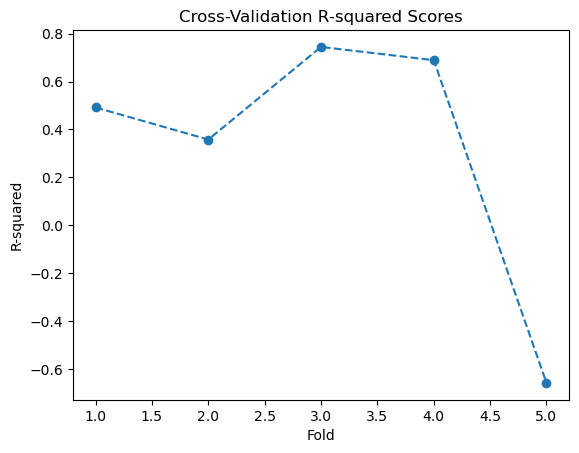

In [70]:
# YOUR CODE HERE
# your code here
# raise NotImplementedError

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)

    test_mse = float(round(mse,3))
    
    r2 = r2_score(y_test, y_pred)

    test_r2 = float(round(r2,3))
    
    return test_mse, test_r2

# CV on k = 5 folds to see how the train/test split is distributed and r-squared changes
# get mean r-squared to get an average of variance from target against features.
# NOTE: this was on NON-Scaled data so its subject to skewing from outliers.
# this assignment did not ask to scale but it would be best for future explorations.
# Conclusion:
# - R-squared dramatically decreases between 4-5 folds which is interesting. The best is 3 or 4 folds.
# - bias-variance trade off could be interpreted as 
# - r-squared between the "validation set approach" or 80/20 split and CV 5 folds indicates that 
# - 80/20 split was close enought to 4 fold CV 
# - mean r-squared indicates the model is ~30% less effective at minimizing variance on target against features
# - Again, these metrics will likely change on scaled data.
# ref https://www.digitalocean.com/community/tutorials/multiple-linear-regression-python
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
# https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation
from sklearn.model_selection import cross_val_score
# scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-Validation Scores:", scores)
print("Mean CV R^2:", scores.mean())

# Line Plot for Cross-Validation Scores
plt.plot(range(1, 6), scores, marker='o', linestyle='--')
plt.xlabel('Fold')
plt.ylabel('R-squared')
plt.title('Cross-Validation R-squared Scores')
plt.show()


In [50]:
# If all tests pass (there might be hidden tests), you will earn 20 points
# Test Cell: Question 7
test_mse, test_r2 = evaluate_model(model, X_test, y_test)
assert isinstance(test_mse, float) and isinstance(
    test_r2, float
), "Function must return two floats."
assert test_mse >= 0, "MSE must be non-negative."
assert test_r2 <= 1.0, "R-squared cannot exceed 1.0."
print(f"Function returned MSE: {test_mse:.3f}, R²: {test_r2:.3f}")

Function returned MSE: 18.066, R²: 0.646


## 8. Analyze Coefficients *(10 points)*

Identify the feature with the largest *negative* coefficient (i.e., the one that most negatively impacts MPG). Store its name as a string in **`q8_strongest_negative_feature`**.

[-0.00935113 -0.04847209 -0.00502316 -0.05942766]
Index(['displacement', 'horsepower', 'weight', 'acceleration'], dtype='object')
3
acceleration
displacement   -0.009351
horsepower     -0.048472
weight         -0.005023
acceleration   -0.059428
dtype: float64


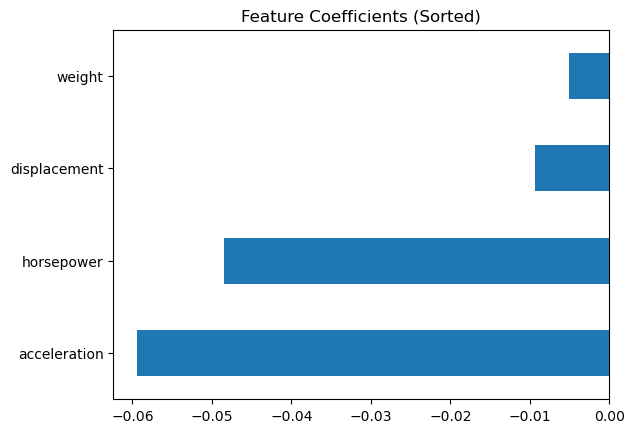

1252
313


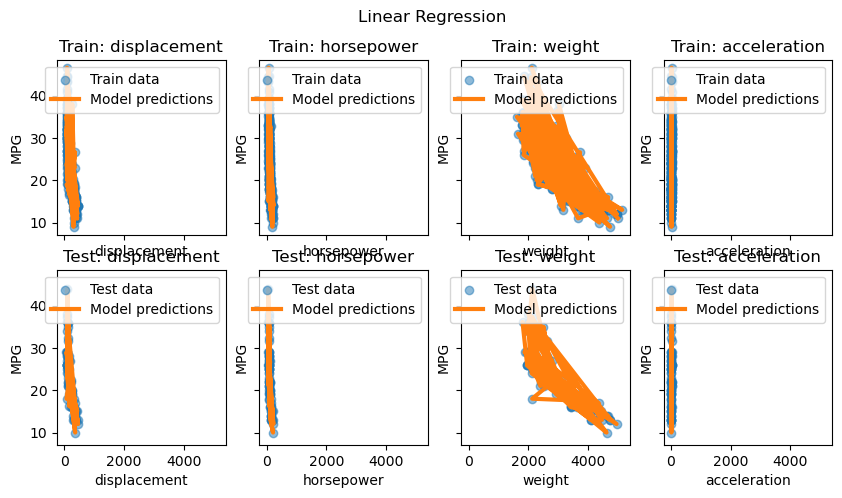

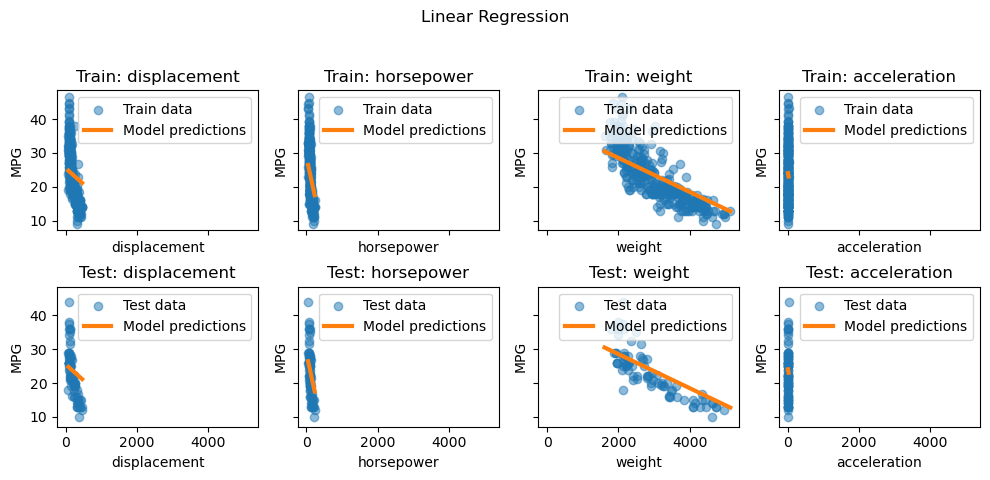

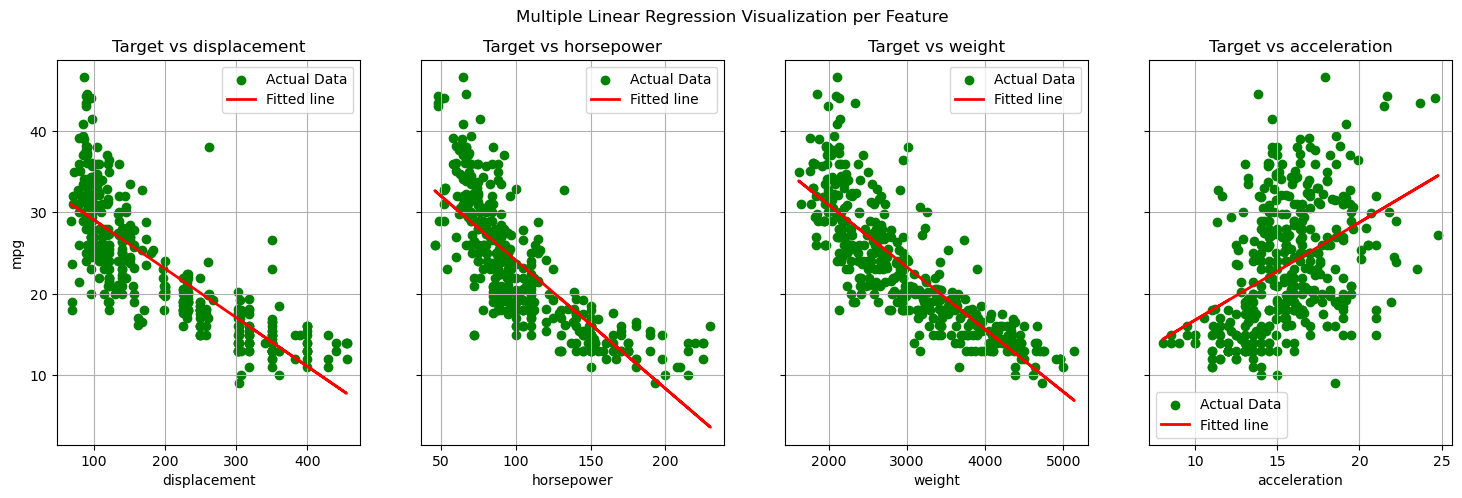

In [76]:
# YOUR CODE HERE
# your code here
# raise NotImplementedError

# explorations

# DID NOT scale or standarize training or test dataset so there is likely skewing going on

# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
# "Estimated coefficients for the linear regression problem. If multiple targets are passed during 
# the fit (y 2D), this is a 2D array of shape (n_targets, n_features), while if only one target is passed, 
# this is a 1D array of length n_features."
print(model.coef_)
print(features)

# min coef
# ref https://numpy.org/doc/stable/reference/generated/numpy.argmin.html#numpy-argmin
min_coef_index = np.argmin(model.coef_, axis=0)
min_coef_label = features[min_coef_index]
print(min_coef_index)
print(min_coef_label)

# 2. Map coefficients to feature names
coef_series = pd.Series(model.coef_, index=X_train.columns)
print(coef_series)

import matplotlib.pyplot as plt

coef_series.sort_values().plot(kind='barh')
plt.title("Feature Coefficients (Sorted)")
plt.show()

print(X_train.size)
print(y_train.size)

fig0, axes0 = plt.subplots(nrows=2, ncols=q2_num_features, figsize=(10, 5), sharex=True, sharey=True)

for idx, feature in enumerate(X_train.columns):
#     Does not work since I get a jagged line due to not predicting per feature
#     fix is to set others to a constant some how...

#     Train set
    axes0[0, idx].scatter(X_train[feature], y_train, alpha=0.5, label="Train data")
    axes0[0, idx].plot(X_train[feature], y_train, linewidth=3, color="tab:orange", label="Model predictions")
    axes0[0, idx].set(xlabel=feature, ylabel="MPG", title=f"Train: {feature}")
    axes0[0, idx].legend()
    
    # Test set
    axes0[1, idx].scatter(X_test[feature], y_test, alpha=0.5, label="Test data")
    axes0[1, idx].plot(X_test[feature], y_test, linewidth=3, color="tab:orange", label="Model predictions")

    # Sort for smooth prediction line
#     test_sorted = X_test[[feature]].sort_values(feature)
#     y_test_pred_sorted = model.predict(X_test.loc[test_sorted.index])
#     axes[1, idx].plot(test_sorted[feature], y_test_pred_sorted, linewidth=3, color="tab:orange", label="Model predictions")
    
    axes0[1, idx].set(xlabel=feature, ylabel="MPG", title=f"Test: {feature}")
    axes0[1, idx].legend()
    
fig0.suptitle("Linear Regression")
# plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect for suptitle
# fig.subplots_adjust(hspace=0.4)  # Increase vertical space between rows
plt.show()


fig, axes = plt.subplots(nrows=2, ncols=q2_num_features, figsize=(10, 5), sharex=True, sharey=True)

for idx, feature in enumerate(X_train.columns):
#   This seems to work but its unclear how exactly. 
#   Took it from AI via Copilot Claude Sonnet 4.5 with prompts on fixing the line jag 
#   The next solution I think is better since it trains & predicts on individual features but 
#   lacks the train/test comparison
    # Create a synthetic dataset: vary this feature, keep others at their mean
    feature_range = np.linspace(X_train[feature].min(), X_train[feature].max(), 100)
    X_synthetic = pd.DataFrame({col: X_train[col].mean() for col in X_train.columns}, index=range(100))
    X_synthetic[feature] = feature_range
    y_synthetic_pred = model.predict(X_synthetic)
    
    # Train set
    axes[0, idx].scatter(X_train[feature], y_train, alpha=0.5, label="Train data")
    axes[0, idx].plot(feature_range, y_synthetic_pred, linewidth=3, color="tab:orange", label="Model predictions")
    axes[0, idx].set(xlabel=feature, ylabel="MPG", title=f"Train: {feature}")
    axes[0, idx].legend()
    
    # Test set
    axes[1, idx].scatter(X_test[feature], y_test, alpha=0.5, label="Test data")
    axes[1, idx].plot(feature_range, y_synthetic_pred, linewidth=3, color="tab:orange", label="Model predictions")
    axes[1, idx].set(xlabel=feature, ylabel="MPG", title=f"Test: {feature}")
    axes[1, idx].legend()

# Adjust layout to prevent overlapping
fig.suptitle("Linear Regression")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect for suptitle
fig.subplots_adjust(hspace=0.4)  # Increase vertical space between rows
plt.show()


#   Took it from Google AI Mode (gemini) via prompt "how to plot multiple linear regression matplotlib with subplots"
#   Set up the subplot grid (1 row, 3 columns for 3 features)
fig2, axes = plt.subplots(nrows=1, ncols=q2_num_features, figsize=(18, 5), sharey=True)
fig2.suptitle('Multiple Linear Regression Visualization per Feature')

# Iterate through features and plot on each axis
for i, feature in enumerate(X_train.columns):
    ax = axes[i] # Select the current axis

    # Prepare data for sklearn (needs 2D array for X)
    X_single = df[[feature]].values
    y = df["mpg"].values

    # Fit linear regression model for the single feature
    model_temp = LinearRegression()
    model_temp.fit(X_single, y)
    y_pred = model_temp.predict(X_single)

    # Plot scatter points and the regression line
    ax.scatter(X_single, y, color='green', label='Actual Data')
    ax.plot(X_single, y_pred, color='red', linewidth=2, label='Fitted line')

    # Customize the subplot
    ax.set_title(f'Target vs {feature}')
    ax.set_xlabel(feature)
    if i == 0: # Only set ylabel for the first plot if sharey is True
        ax.set_ylabel("mpg")
    ax.legend()
    ax.grid(True)

# other ref
# https://www.digitalocean.com/community/tutorials/multiple-linear-regression-python
# https://www.geeksforgeeks.org/machine-learning/ml-multiple-linear-regression-using-python/
# https://www.geeksforgeeks.org/python/plot-multiple-plots-in-matplotlib/
    
# print(max(coef_series.values()))

# explorations END


# Identify the feature with the largest negative coefficient 
# (i.e., the one that most negatively impacts MPG). Store its name as a string in q8_strongest_negative_feature
q8_strongest_negative_feature = min_coef_label



In [77]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 8
assert isinstance(q8_strongest_negative_feature, str), "Answer must be a string."
assert len(q8_strongest_negative_feature) > 0, "Feature name cannot be empty."
assert (
    q8_strongest_negative_feature in X.columns
), "Feature name must be one of the columns in X."
print(f"Feature with most negative coefficient: {q8_strongest_negative_feature}")

Feature with most negative coefficient: acceleration


## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.
